Loaded 5 images


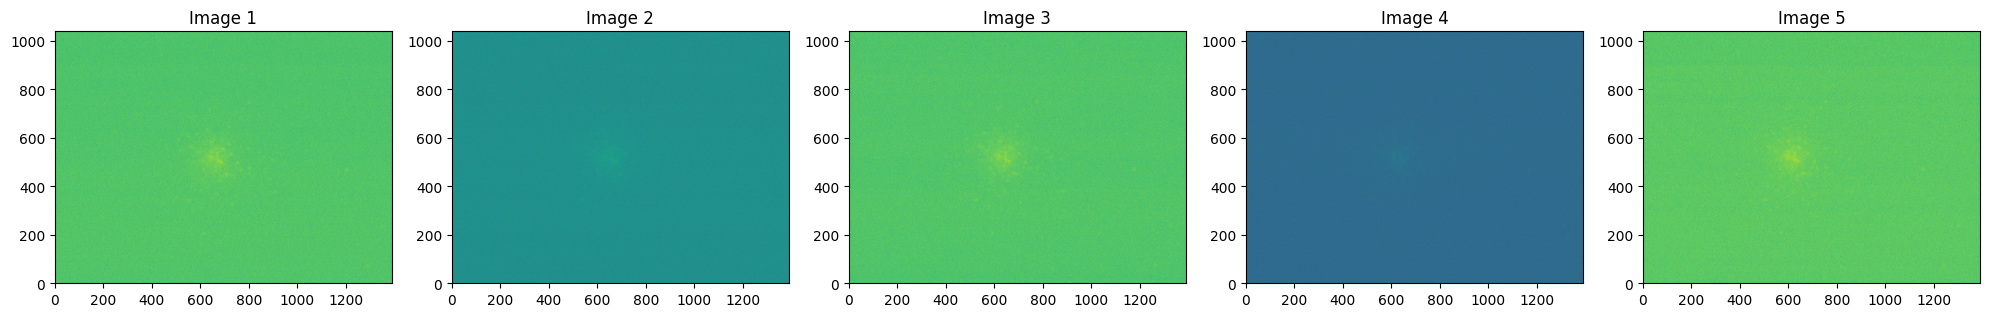

/var/folders/5q/nv84lv0x23d9ng2g70x9rcph0000gn/T/ipykernel_62295/1911472508.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


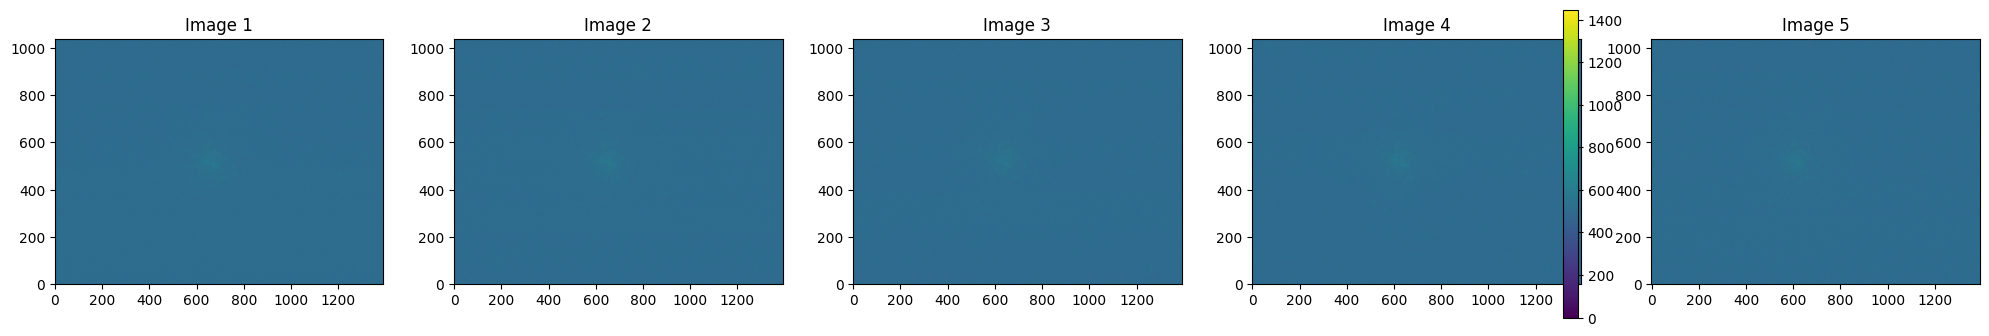


Differences noticed:
- All images now use the same brightness scale
- Relative brightness differences are easier to compare
- Some stars/details may appear dimmer or brighter compared to auto-scaling



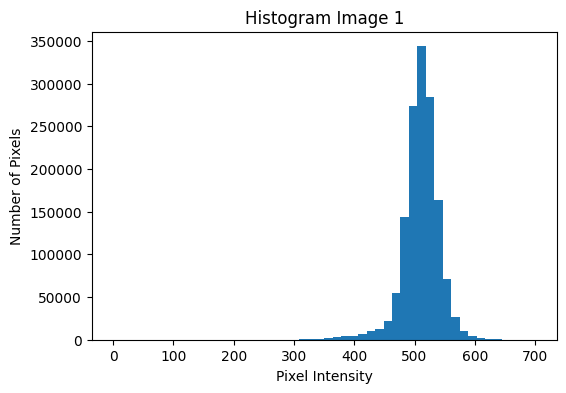

Image 1
Mean: 510.4706668600796
Median: 512.0



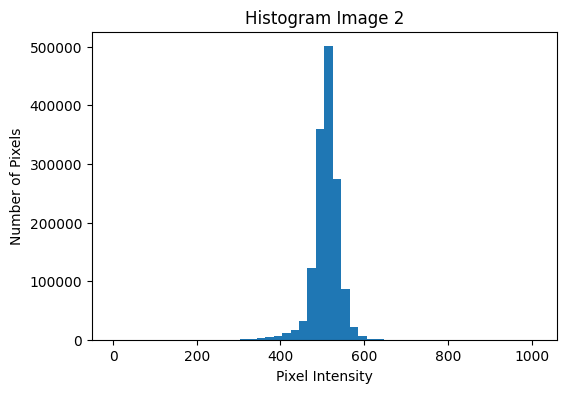

Image 2
Mean: 509.7460150033157
Median: 511.0



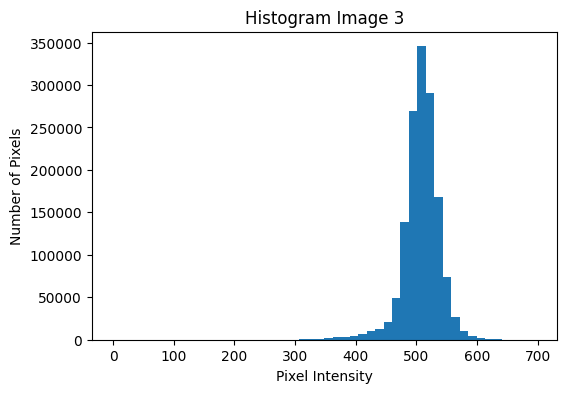

Image 3
Mean: 508.0498729000884
Median: 510.0



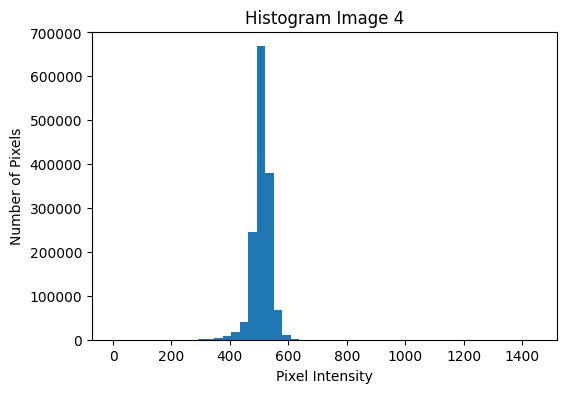

Image 4
Mean: 507.90583554376656
Median: 509.0



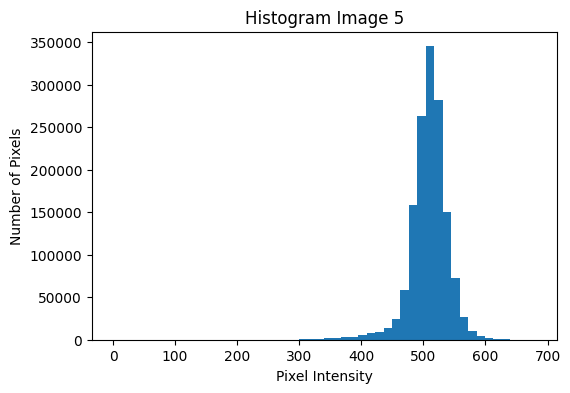

Image 5
Mean: 508.7919920148099
Median: 510.0


(a)
x-axis  -> pixel intensity values
y-axis  -> number of pixels

(b)
bins=50 means the histogram divides the data
into 50 intervals/groups.

(c)
Most data is centered around the background intensity values.

(d)
The data is moderately spread out, with a few bright outliers
coming from stars.

(e)
Means and medians printed above.

Combined image median pixel intensity:
510.0


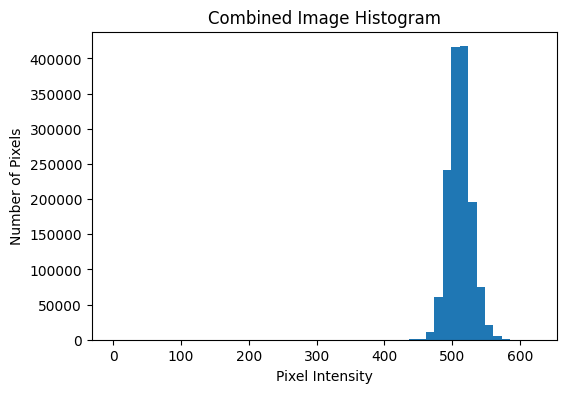

vmin = 460.0
vmax = 560.0


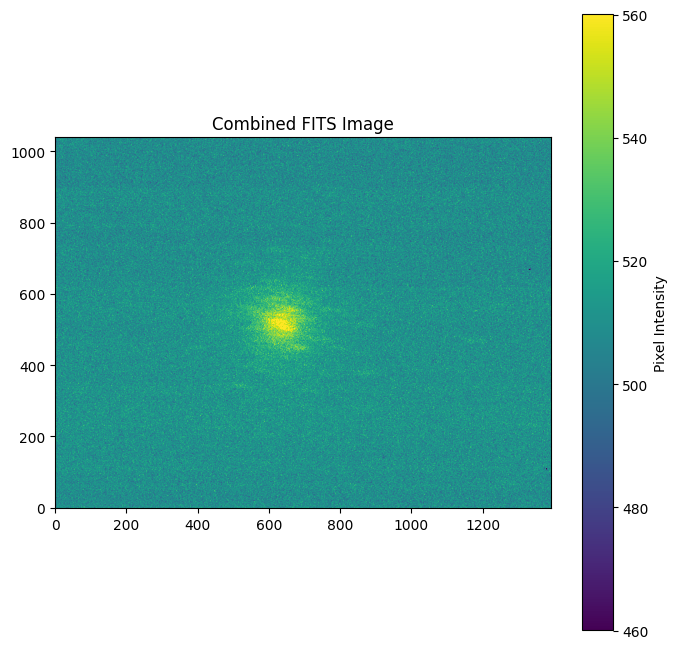


Compared to the earlier versions:
- The combined image has less random noise
- Fainter stars/details are easier to see
- The image appears smoother and clearer

combined.fits saved successfully!


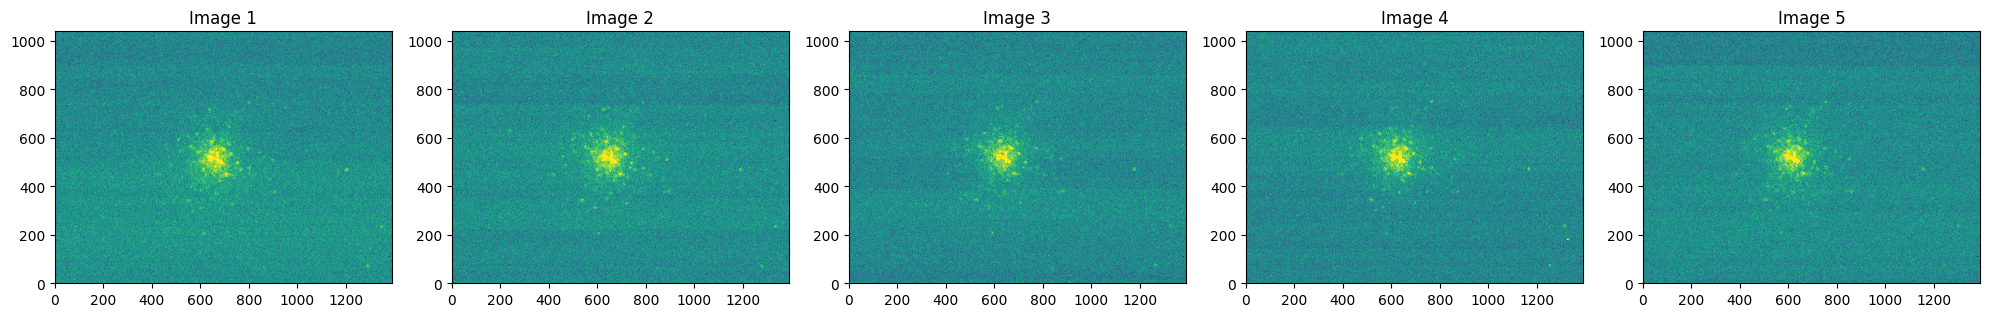

In [1]:
# fits.ipynb

# ============================================================
# 3.1 Read FITS Files
# ============================================================

import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

# List of FITS filenames
fits_files = [
    "M13_0001.fits",
    "M13_0002.fits",
    "M13_0003.fits",
    "M13_0004.fits",
    "M13_0005.fits"
]

# Store image data
images = []

# Load FITS files
for file in fits_files:

    with fits.open(file) as hdul:

        header = hdul[0].header
        data = hdul[0].data

        images.append(data)

print("Loaded", len(images), "images")

# ============================================================
# 3.2 Plot Images
# ============================================================

# ------------------------------------------------------------
# First set of plots
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):

    axes[i].imshow(images[i], origin="lower")
    axes[i].set_title(f"Image {i+1}")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Second set with shared color scale
# ------------------------------------------------------------

# Find common vmin/vmax
vmin = min(np.min(img) for img in images)
vmax = max(np.max(img) for img in images)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):

    im = axes[i].imshow(
        images[i],
        origin="lower",
        vmin=vmin,
        vmax=vmax
    )

    axes[i].set_title(f"Image {i+1}")

# Shared colorbar
fig.colorbar(im, ax=axes.ravel().tolist())

plt.tight_layout()
plt.show()

print("""
Differences noticed:
- All images now use the same brightness scale
- Relative brightness differences are easier to compare
- Some stars/details may appear dimmer or brighter compared to auto-scaling
""")

# ============================================================
# 3.3 Plot Histograms
# ============================================================

means = []
medians = []

for i, data in enumerate(images):

    plt.figure(figsize=(6,4))

    plt.hist(data.ravel(), bins=50)

    plt.title(f"Histogram Image {i+1}")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Number of Pixels")

    plt.show()

    mean_val = np.mean(data)
    median_val = np.median(data)

    means.append(mean_val)
    medians.append(median_val)

    print(f"Image {i+1}")
    print("Mean:", mean_val)
    print("Median:", median_val)
    print()

print("""
(a)
x-axis  -> pixel intensity values
y-axis  -> number of pixels

(b)
bins=50 means the histogram divides the data
into 50 intervals/groups.

(c)
Most data is centered around the background intensity values.

(d)
The data is moderately spread out, with a few bright outliers
coming from stars.

(e)
Means and medians printed above.
""")

# ============================================================
# 3.4 Combine and Normalize Images
# ============================================================

# Combine images using median
combined_image = np.median(images, axis=0)

# Median pixel intensity
combined_median = np.median(combined_image)

print("Combined image median pixel intensity:")
print(combined_median)

# ------------------------------------------------------------
# Histogram of combined image
# ------------------------------------------------------------

plt.figure(figsize=(6,4))

plt.hist(combined_image.ravel(), bins=50)

plt.title("Combined Image Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")

plt.show()

# ------------------------------------------------------------
# Choose vmin/vmax from histogram region
# ------------------------------------------------------------

vmin = combined_median - 50
vmax = combined_median + 50

print("vmin =", vmin)
print("vmax =", vmax)

# ------------------------------------------------------------
# Plot combined image
# ------------------------------------------------------------

plt.figure(figsize=(8,8))

plt.imshow(
    combined_image,
    origin="lower",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="Pixel Intensity")

plt.title("Combined FITS Image")

plt.show()

print("""
Compared to the earlier versions:
- The combined image has less random noise
- Fainter stars/details are easier to see
- The image appears smoother and clearer
""")

# ------------------------------------------------------------
# Save combined FITS image
# ------------------------------------------------------------

fits.writeto(
    "combined.fits",
    combined_image,
    overwrite=True
)

print("combined.fits saved successfully!")

# ============================================================
# 3.5 Bonus
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(20,4))

for i in range(5):

    axes[i].imshow(
        images[i],
        origin="lower",
        vmin=vmin,
        vmax=vmax
    )

    axes[i].set_title(f"Image {i+1}")

plt.tight_layout()
plt.show()